In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pydicom
from tqdm import tqdm
import xml.etree.ElementTree as ET
from io import BytesIO
import zipfile

In [8]:
PROJECT_ROOT = Path(r"F:/AstraZeneca/project/chestCT/CHEST_CT_NSCLC")

LIDC_ROOT = PROJECT_ROOT / "data" / "raw" / "LIDC"
LIDC_MANIFEST_ROOT = LIDC_ROOT / "manifest-1600709154662"
LIDC_DICOM_ROOT = LIDC_MANIFEST_ROOT / "LIDC-IDRI"
LIDC_METADATA_PATH = LIDC_MANIFEST_ROOT / "metadata.csv"
LIDC_XML_ROOT = LIDC_ROOT / "tcia-lidc-xml"

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
TABLE_DIR = PROCESSED_DIR / "tables"
FIGURE_DIR = PROCESSED_DIR / "figures"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("LIDC_ROOT exists:", LIDC_ROOT.exists(), LIDC_ROOT)
print("LIDC_DICOM_ROOT exists:", LIDC_DICOM_ROOT.exists(), LIDC_DICOM_ROOT)
print("LIDC_METADATA_PATH exists:", LIDC_METADATA_PATH.exists(), LIDC_METADATA_PATH)
print("LIDC_XML_ROOT exists:", LIDC_XML_ROOT.exists(), LIDC_XML_ROOT)

print("PROCESSED_DIR:", PROCESSED_DIR)
print("TABLE_DIR:", TABLE_DIR)
print("FIGURE_DIR:", FIGURE_DIR)

PROJECT_ROOT: F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC
LIDC_ROOT exists: True F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\data\raw\LIDC
LIDC_DICOM_ROOT exists: True F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\data\raw\LIDC\manifest-1600709154662\LIDC-IDRI
LIDC_METADATA_PATH exists: True F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\data\raw\LIDC\manifest-1600709154662\metadata.csv
LIDC_XML_ROOT exists: True F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\data\raw\LIDC\tcia-lidc-xml
PROCESSED_DIR: F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\data\processed
TABLE_DIR: F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\data\processed\tables
FIGURE_DIR: F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\data\processed\figures


In [9]:
# Load LIDC metadata csv
lidc_metadata = pd.read_csv(LIDC_METADATA_PATH)

print("LIDC metadata shape:", lidc_metadata.shape)
display(lidc_metadata.head())
print("Columns:")
print(lidc_metadata.columns.tolist())

lidc_metadata.to_csv(TABLE_DIR / "lidc_metadata_copy.csv", index=False)

LIDC metadata shape: (1308, 17)


,Series UID,Collection,3rd Party Analysis,Data Description URI,Subject ID,Study UID,Study Description,Study Date,Series Description,Manufacturer,Modality,SOP Class Name,SOP Class UID,Number of Images,File Size,File Location,Download Timestamp
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.493562949900...,LIDC-IDRI,NaN,https://doi.org/10.7937/K9/TCIA.2015.LO9QL9SX,LIDC-IDRI-0002,1.3.6.1.4.1.14519.5.2.1.6279.6001.116951808801...,NaN,01-01-2000,NaN,GE MEDICAL SYSTEMS,DX,Digital X-Ray Image Storage - For Presentation,1.2.840.10008.5.1.4.1.1.1.1,1,6.91 MB,.\LIDC-IDRI\LIDC-IDRI-0002\01-01-2000-NA-NA-26...,2026-05-28T13:52:01.568
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.141365756818...,LIDC-IDRI,NaN,https://doi.org/10.7937/K9/TCIA.2015.LO9QL9SX,LIDC-IDRI-0001,1.3.6.1.4.1.14519.5.2.1.6279.6001.175012972118...,NaN,01-01-2000,NaN,GE MEDICAL SYSTEMS,DX,Digital X-Ray Image Storage - For Presentation,1.2.840.10008.5.1.4.1.1.1.1,2,16.36 MB,.\LIDC-IDRI\LIDC-IDRI-0001\01-01-2000-NA-NA-35...,2026-05-28T13:52:11.413
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.179049373636...,LIDC-IDRI,NaN,https://doi.org/10.7937/K9/TCIA.2015.LO9QL9SX,LIDC-IDRI-0001,1.3.6.1.4.1.14519.5.2.1.6279.6001.298806137288...,NaN,01-01-2000,NaN,GE MEDICAL SYSTEMS,CT,CT Image Storage,1.2.840.10008.5.1.4.1.1.2,133,70.33 MB,.\LIDC-IDRI\LIDC-IDRI-0001\01-01-2000-NA-NA-30...,2026-05-28T13:53:04.604
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.170706757615...,LIDC-IDRI,NaN,https://doi.org/10.7937/K9/TCIA.2015.LO9QL9SX,LIDC-IDRI-0003,1.3.6.1.4.1.14519.5.2.1.6279.6001.101370605276...,NaN,01-01-2000,NaN,GE MEDICAL SYSTEMS,CT,CT Image Storage,1.2.840.10008.5.1.4.1.1.2,140,74.11 MB,.\LIDC-IDRI\LIDC-IDRI-0003\01-01-2000-NA-NA-94...,2026-05-28T13:53:24.853
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.142026812390...,LIDC-IDRI,NaN,https://doi.org/10.7937/K9/TCIA.2015.LO9QL9SX,LIDC-IDRI-0003,1.3.6.1.4.1.14519.5.2.1.6279.6001.202063331127...,NaN,01-01-2000,NaN,GE MEDICAL SYSTEMS,DX,Digital X-Ray Image Storage - For Presentation,1.2.840.10008.5.1.4.1.1.1.1,5,38.59 MB,.\LIDC-IDRI\LIDC-IDRI-0003\01-01-2000-NA-NA-59...,2026-05-28T13:53:28.072


Columns:
['Series UID', 'Collection', '3rd Party Analysis', 'Data Description URI', 'Subject ID', 'Study UID', 'Study Description', 'Study Date', 'Series Description', 'Manufacturer', 'Modality', 'SOP Class Name', 'SOP Class UID', 'Number of Images', 'File Size', 'File Location', 'Download Timestamp']


In [10]:
patient_dirs = sorted([
    p for p in LIDC_DICOM_ROOT.glob("LIDC-IDRI-*")
    if p.is_dir()
])

print("Number of LIDC patient folders:", len(patient_dirs))
print("First 10 patient folders:")

for p in patient_dirs[:10]:
    print(p.name)

Number of LIDC patient folders: 1010
First 10 patient folders:
LIDC-IDRI-0001
LIDC-IDRI-0002
LIDC-IDRI-0003
LIDC-IDRI-0004
LIDC-IDRI-0005
LIDC-IDRI-0006
LIDC-IDRI-0007
LIDC-IDRI-0008
LIDC-IDRI-0009
LIDC-IDRI-0010


In [11]:
xml_files = sorted(LIDC_XML_ROOT.rglob("*.xml"))

print("Number of XML files:", len(xml_files))
print("First 10 XML files:")

for f in xml_files[:10]:
    print(f)

Number of XML files: 1318
First 10 XML files:
F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\data\raw\LIDC\tcia-lidc-xml\157\158.xml
F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\data\raw\LIDC\tcia-lidc-xml\157\159.xml
F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\data\raw\LIDC\tcia-lidc-xml\157\160.xml
F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\data\raw\LIDC\tcia-lidc-xml\157\161.xml
F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\data\raw\LIDC\tcia-lidc-xml\157\162.xml
F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\data\raw\LIDC\tcia-lidc-xml\157\163.xml
F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\data\raw\LIDC\tcia-lidc-xml\157\164.xml
F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\data\raw\LIDC\tcia-lidc-xml\157\165.xml
F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\data\raw\LIDC\tcia-lidc-xml\157\166.xml
F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\data\raw\LIDC\tcia-lidc-xml\157\167.xml


In [12]:
sample_patient = patient_dirs[0]

all_files = [f for f in sample_patient.rglob("*") if f.is_file()]

print("Sample patient:", sample_patient.name)
print("Number of files under this patient:", len(all_files))

dicom_files = []

for f in all_files:
    try:
        ds = pydicom.dcmread(str(f), stop_before_pixels=True, force=True)
        if getattr(ds, "Modality", None) == "CT":
            dicom_files.append(f)
    except Exception:
        pass

print("Number of CT DICOM files:", len(dicom_files))
print("First CT DICOM file:", dicom_files[0] if dicom_files else None)

Sample patient: LIDC-IDRI-0001
Number of files under this patient: 137
Number of CT DICOM files: 133
First CT DICOM file: F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\data\raw\LIDC\manifest-1600709154662\LIDC-IDRI\LIDC-IDRI-0001\01-01-2000-NA-NA-30178\3000566.000000-NA-03192\1-001.dcm


PatientID: LIDC-IDRI-0001
StudyInstanceUID: 1.3.6.1.4.1.14519.5.2.1.6279.6001.298806137288633453246975630178
SeriesInstanceUID: 1.3.6.1.4.1.14519.5.2.1.6279.6001.179049373636438705059720603192
Rows, Columns: 512 512
PixelSpacing: [0.703125, 0.703125]
SliceThickness: 2.500000
RescaleSlope: 1.0
RescaleIntercept: -1024.0
HU range: -2048.0 3071.0


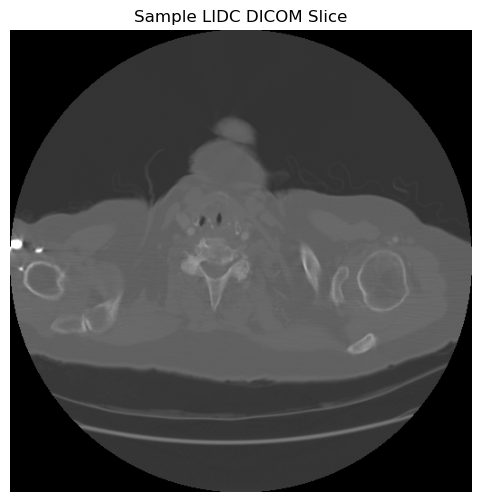

In [13]:
ds = pydicom.dcmread(str(dicom_files[0]), force=True)

pixel_array = ds.pixel_array.astype(np.float32)

slope = float(getattr(ds, "RescaleSlope", 1))
intercept = float(getattr(ds, "RescaleIntercept", 0))

hu_image = pixel_array * slope + intercept

print("PatientID:", getattr(ds, "PatientID", None))
print("StudyInstanceUID:", getattr(ds, "StudyInstanceUID", None))
print("SeriesInstanceUID:", getattr(ds, "SeriesInstanceUID", None))
print("Rows, Columns:", ds.Rows, ds.Columns)
print("PixelSpacing:", getattr(ds, "PixelSpacing", None))
print("SliceThickness:", getattr(ds, "SliceThickness", None))
print("RescaleSlope:", slope)
print("RescaleIntercept:", intercept)
print("HU range:", hu_image.min(), hu_image.max())

plt.figure(figsize=(6, 6))
plt.imshow(hu_image, cmap="gray")
plt.title("Sample LIDC DICOM Slice")
plt.axis("off")
plt.show()

plt.imsave(FIGURE_DIR / "lidc_sample_slice.png", hu_image, cmap="gray")

In [14]:
def read_dicom_header(file_path):
    try:
        ds = pydicom.dcmread(str(file_path), stop_before_pixels=True, force=True)

        if not hasattr(ds, "SeriesInstanceUID"):
            return None

        return {
            "PatientID": getattr(ds, "PatientID", None),
            "StudyInstanceUID": getattr(ds, "StudyInstanceUID", None),
            "SeriesInstanceUID": getattr(ds, "SeriesInstanceUID", None),
            "Modality": getattr(ds, "Modality", None),
            "Rows": getattr(ds, "Rows", None),
            "Columns": getattr(ds, "Columns", None),
            "SliceThickness": getattr(ds, "SliceThickness", None),
            "PixelSpacing": str(getattr(ds, "PixelSpacing", None)),
            "Manufacturer": getattr(ds, "Manufacturer", None),
            "ConvolutionKernel": getattr(ds, "ConvolutionKernel", None),
        }

    except Exception:
        return None
    
inventory_path = TABLE_DIR / "lidc_series_inventory.csv"

if inventory_path.exists():
    print("Existing inventory found. Loading:", inventory_path)
    lidc_series_df = pd.read_csv(inventory_path)
else:
    series_records = []

    for patient_dir in tqdm(patient_dirs, desc="Scanning LIDC patients"):
        files = [f for f in patient_dir.rglob("*") if f.is_file()]

        patient_headers = []

        for f in files:
            header = read_dicom_header(f)
            if header is not None:
                header["patient_folder"] = patient_dir.name
                header["file_path"] = str(f)
                patient_headers.append(header)

        if len(patient_headers) == 0:
            continue

        patient_df = pd.DataFrame(patient_headers)

        grouped = (
            patient_df
            .groupby(
                [
                    "patient_folder",
                    "PatientID",
                    "StudyInstanceUID",
                    "SeriesInstanceUID",
                    "Modality",
                    "Rows",
                    "Columns",
                    "SliceThickness",
                    "PixelSpacing",
                    "Manufacturer",
                    "ConvolutionKernel",
                ],
                dropna=False
            )
            .size()
            .reset_index(name="num_slices")
        )

        series_records.append(grouped)

    lidc_series_df = pd.concat(series_records, ignore_index=True)
    lidc_series_df.to_csv(inventory_path, index=False)

display(lidc_series_df.head())

print("Total series:", len(lidc_series_df))
print("CT series:", (lidc_series_df["Modality"] == "CT").sum())
print("Saved to:", inventory_path)

Scanning LIDC patients: 100%|██████████| 1010/1010 [36:56<00:00,  2.20s/it] 


,patient_folder,PatientID,StudyInstanceUID,SeriesInstanceUID,Modality,Rows,Columns,SliceThickness,PixelSpacing,Manufacturer,ConvolutionKernel,num_slices
0,LIDC-IDRI-0001,LIDC-IDRI-0001,1.3.6.1.4.1.14519.5.2.1.6279.6001.175012972118...,1.3.6.1.4.1.14519.5.2.1.6279.6001.141365756818...,DX,2022,2022,NaN,None,GE MEDICAL SYSTEMS,NaN,2
1,LIDC-IDRI-0001,LIDC-IDRI-0001,1.3.6.1.4.1.14519.5.2.1.6279.6001.298806137288...,1.3.6.1.4.1.14519.5.2.1.6279.6001.179049373636...,CT,512,512,2.50,"[0.703125, 0.703125]",GE MEDICAL SYSTEMS,STANDARD,133
2,LIDC-IDRI-0002,LIDC-IDRI-0002,1.3.6.1.4.1.14519.5.2.1.6279.6001.116951808801...,1.3.6.1.4.1.14519.5.2.1.6279.6001.493562949900...,DX,2007,1721,NaN,None,GE MEDICAL SYSTEMS,NaN,1
3,LIDC-IDRI-0002,LIDC-IDRI-0002,1.3.6.1.4.1.14519.5.2.1.6279.6001.490157381160...,1.3.6.1.4.1.14519.5.2.1.6279.6001.619372068417...,CT,512,512,1.25,"[0.681641, 0.681641]",GE MEDICAL SYSTEMS,STANDARD,261
4,LIDC-IDRI-0003,LIDC-IDRI-0003,1.3.6.1.4.1.14519.5.2.1.6279.6001.101370605276...,1.3.6.1.4.1.14519.5.2.1.6279.6001.170706757615...,CT,512,512,2.50,"[0.820312, 0.820312]",GE MEDICAL SYSTEMS,STANDARD,140


Total series: 1362
CT series: 1018
Saved to: F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\data\processed\tables\lidc_series_inventory.csv


In [15]:
lidc_ct_series_df = lidc_series_df[lidc_series_df["Modality"] == "CT"].copy()

main_ct_series_df = (
    lidc_ct_series_df
    .sort_values(["patient_folder", "num_slices"], ascending=[True, False])
    .groupby("patient_folder")
    .head(1)
    .reset_index(drop=True)
)

main_ct_series_path = TABLE_DIR / "lidc_main_ct_series.csv"
main_ct_series_df.to_csv(main_ct_series_path, index=False)

display(main_ct_series_df.head())

print("Number of main CT series:", len(main_ct_series_df))
print("Saved to:", main_ct_series_path)

,patient_folder,PatientID,StudyInstanceUID,SeriesInstanceUID,Modality,Rows,Columns,SliceThickness,PixelSpacing,Manufacturer,ConvolutionKernel,num_slices
0,LIDC-IDRI-0001,LIDC-IDRI-0001,1.3.6.1.4.1.14519.5.2.1.6279.6001.298806137288...,1.3.6.1.4.1.14519.5.2.1.6279.6001.179049373636...,CT,512,512,2.50,"[0.703125, 0.703125]",GE MEDICAL SYSTEMS,STANDARD,133
1,LIDC-IDRI-0002,LIDC-IDRI-0002,1.3.6.1.4.1.14519.5.2.1.6279.6001.490157381160...,1.3.6.1.4.1.14519.5.2.1.6279.6001.619372068417...,CT,512,512,1.25,"[0.681641, 0.681641]",GE MEDICAL SYSTEMS,STANDARD,261
2,LIDC-IDRI-0003,LIDC-IDRI-0003,1.3.6.1.4.1.14519.5.2.1.6279.6001.101370605276...,1.3.6.1.4.1.14519.5.2.1.6279.6001.170706757615...,CT,512,512,2.50,"[0.820312, 0.820312]",GE MEDICAL SYSTEMS,STANDARD,140
3,LIDC-IDRI-0004,LIDC-IDRI-0004,1.3.6.1.4.1.14519.5.2.1.6279.6001.191425307197...,1.3.6.1.4.1.14519.5.2.1.6279.6001.323541312620...,CT,512,512,1.25,"[0.822266, 0.822266]",GE MEDICAL SYSTEMS,STANDARD,241
4,LIDC-IDRI-0005,LIDC-IDRI-0005,1.3.6.1.4.1.14519.5.2.1.6279.6001.190188259083...,1.3.6.1.4.1.14519.5.2.1.6279.6001.129007566048...,CT,512,512,2.50,"[0.664062, 0.664062]",GE MEDICAL SYSTEMS,STANDARD,133


Number of main CT series: 1010
Saved to: F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\data\processed\tables\lidc_main_ct_series.csv


In [16]:
def load_lidc_volume_from_patient(patient_dir: Path, series_uid: str):
    dicom_paths = []

    for f in patient_dir.rglob("*"):
        if not f.is_file():
            continue

        try:
            ds = pydicom.dcmread(str(f), stop_before_pixels=True, force=True)

            if getattr(ds, "SeriesInstanceUID", None) == series_uid:
                dicom_paths.append(f)

        except Exception:
            pass

    slices = []

    for f in dicom_paths:
        try:
            ds = pydicom.dcmread(str(f), force=True)

            if hasattr(ds, "pixel_array"):
                slices.append(ds)

        except Exception:
            pass

    if len(slices) == 0:
        raise ValueError("No readable DICOM slices found for this series.")

    def get_slice_position(ds):
        if hasattr(ds, "ImagePositionPatient"):
            return float(ds.ImagePositionPatient[2])
        if hasattr(ds, "SliceLocation"):
            return float(ds.SliceLocation)
        return float(getattr(ds, "InstanceNumber", 0))

    slices = sorted(slices, key=get_slice_position)

    volume = np.stack(
        [s.pixel_array.astype(np.float32) for s in slices],
        axis=0
    )

    slope = float(getattr(slices[0], "RescaleSlope", 1))
    intercept = float(getattr(slices[0], "RescaleIntercept", 0))

    volume_hu = volume * slope + intercept

    spacing = {
        "z": float(getattr(slices[0], "SliceThickness", 1)),
        "y": float(slices[0].PixelSpacing[0]),
        "x": float(slices[0].PixelSpacing[1]),
    }

    return volume_hu, spacing, slices

sample_main = main_ct_series_df.iloc[0]

sample_patient_dir = LIDC_DICOM_ROOT / sample_main["patient_folder"]
sample_series_uid = sample_main["SeriesInstanceUID"]

volume_hu, spacing, slices = load_lidc_volume_from_patient(
    sample_patient_dir,
    sample_series_uid
)

print("Sample patient:", sample_main["patient_folder"])
print("SeriesInstanceUID:", sample_series_uid)
print("Volume shape:", volume_hu.shape)   # z, y, x
print("Spacing:", spacing)
print("HU range:", volume_hu.min(), volume_hu.max())

Sample patient: LIDC-IDRI-0001
SeriesInstanceUID: 1.3.6.1.4.1.14519.5.2.1.6279.6001.179049373636438705059720603192
Volume shape: (133, 512, 512)
Spacing: {'z': 2.5, 'y': 0.703125, 'x': 0.703125}
HU range: -2048.0 3071.0


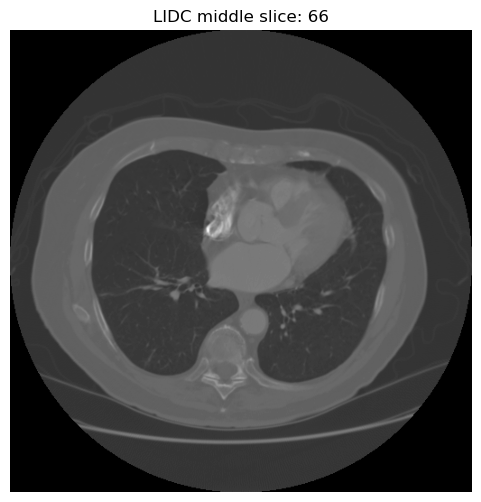

Saved figure to: F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\data\processed\figures\lidc_sample_middle_slice.png


In [17]:
mid = volume_hu.shape[0] // 2

plt.figure(figsize=(6, 6))
plt.imshow(volume_hu[mid], cmap="gray")
plt.title(f"LIDC middle slice: {mid}")
plt.axis("off")
plt.show()

plt.imsave(
    FIGURE_DIR / "lidc_sample_middle_slice.png",
    volume_hu[mid],
    cmap="gray"
)

print("Saved figure to:", FIGURE_DIR / "lidc_sample_middle_slice.png")

In [18]:
def local_name(tag):
    return tag.split("}", 1)[-1] if "}" in tag else tag


def find_first_text(root, target_name):
    for elem in root.iter():
        if local_name(elem.tag) == target_name:
            return elem.text
    return None


def get_child_text(parent, target_name):
    for child in parent:
        if local_name(child.tag) == target_name:
            return child.text
    return None


def parse_lidc_xml(xml_path: Path):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    series_uid = (
        find_first_text(root, "SeriesInstanceUid")
        or find_first_text(root, "SeriesInstanceUID")
        or find_first_text(root, "seriesInstanceUid")
    )

    study_uid = (
        find_first_text(root, "StudyInstanceUID")
        or find_first_text(root, "StudyInstanceUid")
        or find_first_text(root, "studyInstanceUid")
    )

    rows = []

    reading_sessions = [
        elem for elem in root.iter()
        if local_name(elem.tag) == "readingSession"
    ]

    for reader_index, session in enumerate(reading_sessions, start=1):

        nodules = [
            elem for elem in session
            if local_name(elem.tag) == "unblindedReadNodule"
        ]

        for nodule in nodules:
            nodule_id = get_child_text(nodule, "noduleID")

            characteristics = None

            for child in nodule:
                if local_name(child.tag) == "characteristics":
                    characteristics = child
                    break

            malignancy = None
            subtlety = None
            internal_structure = None
            calcification = None
            sphericity = None
            margin = None
            lobulation = None
            spiculation = None
            texture = None

            if characteristics is not None:
                malignancy = get_child_text(characteristics, "malignancy")
                subtlety = get_child_text(characteristics, "subtlety")
                internal_structure = get_child_text(characteristics, "internalStructure")
                calcification = get_child_text(characteristics, "calcification")
                sphericity = get_child_text(characteristics, "sphericity")
                margin = get_child_text(characteristics, "margin")
                lobulation = get_child_text(characteristics, "lobulation")
                spiculation = get_child_text(characteristics, "spiculation")
                texture = get_child_text(characteristics, "texture")

            roi_count = 0
            edge_point_count = 0

            z_positions = []
            x_points = []
            y_points = []

            for roi in nodule.iter():
                if local_name(roi.tag) == "roi":
                    roi_count += 1

                    z_text = get_child_text(roi, "imageZposition")

                    if z_text is not None:
                        try:
                            z_positions.append(float(z_text))
                        except ValueError:
                            pass

                    for edge_map in roi:
                        if local_name(edge_map.tag) == "edgeMap":
                            x_text = get_child_text(edge_map, "xCoord")
                            y_text = get_child_text(edge_map, "yCoord")

                            if x_text is not None and y_text is not None:
                                try:
                                    x_points.append(float(x_text))
                                    y_points.append(float(y_text))
                                    edge_point_count += 1
                                except ValueError:
                                    pass

            row = {
                "xml_file": str(xml_path),
                "xml_name": xml_path.name,
                "StudyInstanceUID": study_uid,
                "SeriesInstanceUID": series_uid,
                "reader_id": reader_index,
                "nodule_id": nodule_id,
                "malignancy": malignancy,
                "subtlety": subtlety,
                "internal_structure": internal_structure,
                "calcification": calcification,
                "sphericity": sphericity,
                "margin": margin,
                "lobulation": lobulation,
                "spiculation": spiculation,
                "texture": texture,
                "roi_count": roi_count,
                "edge_point_count": edge_point_count,
                "z_min": min(z_positions) if z_positions else np.nan,
                "z_max": max(z_positions) if z_positions else np.nan,
                "x_min": min(x_points) if x_points else np.nan,
                "x_max": max(x_points) if x_points else np.nan,
                "y_min": min(y_points) if y_points else np.nan,
                "y_max": max(y_points) if y_points else np.nan,
            }

            rows.append(row)

    return rows

In [19]:
xml_nodules_path = TABLE_DIR / "lidc_xml_nodules_raw.csv"

if xml_nodules_path.exists():
    print("Existing XML nodule table found. Loading:", xml_nodules_path)
    lidc_xml_nodules_df = pd.read_csv(xml_nodules_path)
else:
    all_nodule_rows = []

    for xml_file in tqdm(xml_files, desc="Parsing LIDC XML files"):
        try:
            rows = parse_lidc_xml(xml_file)
            all_nodule_rows.extend(rows)
        except Exception as e:
            print("Failed:", xml_file, e)

    lidc_xml_nodules_df = pd.DataFrame(all_nodule_rows)
    lidc_xml_nodules_df.to_csv(xml_nodules_path, index=False)

display(lidc_xml_nodules_df.head())
print("XML nodule table shape:", lidc_xml_nodules_df.shape)
print("Saved to:", xml_nodules_path)

Parsing LIDC XML files: 100%|██████████| 1318/1318 [00:39<00:00, 33.19it/s]


,xml_file,xml_name,StudyInstanceUID,SeriesInstanceUID,reader_id,nodule_id,malignancy,subtlety,internal_structure,calcification,...,spiculation,texture,roi_count,edge_point_count,z_min,z_max,x_min,x_max,y_min,y_max
0,F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\...,158.xml,1.3.6.1.4.1.14519.5.2.1.6279.6001.339170810277...,1.3.6.1.4.1.14519.5.2.1.6279.6001.303494235102...,1,0,None,None,None,None,...,None,None,1,1,1604.5,1604.5,177.0,177.0,353.0,353.0
1,F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\...,158.xml,1.3.6.1.4.1.14519.5.2.1.6279.6001.339170810277...,1.3.6.1.4.1.14519.5.2.1.6279.6001.303494235102...,1,3,3,5,1,6,...,1,5,6,392,1535.5,1550.5,349.0,375.0,151.0,184.0
2,F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\...,158.xml,1.3.6.1.4.1.14519.5.2.1.6279.6001.339170810277...,1.3.6.1.4.1.14519.5.2.1.6279.6001.303494235102...,1,4,3,4,1,6,...,2,5,6,397,1472.5,1487.5,318.0,345.0,300.0,326.0
3,F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\...,158.xml,1.3.6.1.4.1.14519.5.2.1.6279.6001.339170810277...,1.3.6.1.4.1.14519.5.2.1.6279.6001.303494235102...,1,5,None,None,None,None,...,None,None,1,1,1631.5,1631.5,197.0,197.0,321.0,321.0
4,F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\...,158.xml,1.3.6.1.4.1.14519.5.2.1.6279.6001.339170810277...,1.3.6.1.4.1.14519.5.2.1.6279.6001.303494235102...,1,6,4,5,1,4,...,3,5,8,572,1595.5,1616.5,326.0,360.0,228.0,262.0


XML nodule table shape: (20362, 23)
Saved to: F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\data\processed\tables\lidc_xml_nodules_raw.csv


Malignancy score distribution:
malignancy
0.0        2
1.0     1025
2.0     1654
3.0     2673
4.0      969
5.0      709
NaN    13330
Name: count, dtype: int64


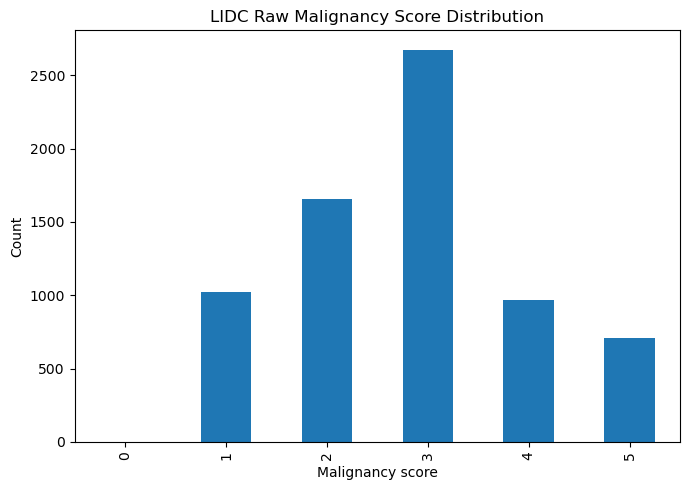

In [20]:
lidc_xml_nodules_df["malignancy"] = pd.to_numeric(
    lidc_xml_nodules_df["malignancy"],
    errors="coerce"
)

malignancy_counts = (
    lidc_xml_nodules_df["malignancy"]
    .value_counts(dropna=False)
    .sort_index()
)

print("Malignancy score distribution:")
print(malignancy_counts)

malignancy_counts.to_csv(
    TABLE_DIR / "lidc_malignancy_score_distribution.csv",
    header=["count"]
)

plt.figure(figsize=(7, 5))
lidc_xml_nodules_df["malignancy"].dropna().astype(int).value_counts().sort_index().plot(kind="bar")
plt.xlabel("Malignancy score")
plt.ylabel("Count")
plt.title("LIDC Raw Malignancy Score Distribution")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "lidc_malignancy_score_distribution.png", dpi=300)
plt.show()

In [21]:
xml_series = set(
    lidc_xml_nodules_df["SeriesInstanceUID"]
    .dropna()
    .astype(str)
    .unique()
)

dicom_series = set(
    main_ct_series_df["SeriesInstanceUID"]
    .dropna()
    .astype(str)
    .unique()
)

matched_series = xml_series.intersection(dicom_series)

print("XML series count:", len(xml_series))
print("Main DICOM CT series count:", len(dicom_series))
print("Matched series count:", len(matched_series))

if len(xml_series) > 0:
    print("Match rate:", len(matched_series) / len(xml_series))
else:
    print("Match rate: N/A")

XML series count: 998
Main DICOM CT series count: 1010
Matched series count: 990
Match rate: 0.9919839679358717


In [22]:
match_summary = pd.DataFrame([
    {
        "xml_series_count": len(xml_series),
        "main_dicom_ct_series_count": len(dicom_series),
        "matched_series_count": len(matched_series),
        "match_rate": len(matched_series) / len(xml_series) if len(xml_series) > 0 else np.nan
    }
])

match_summary.to_csv(TABLE_DIR / "lidc_xml_dicom_match_summary.csv", index=False)

display(match_summary)

,xml_series_count,main_dicom_ct_series_count,matched_series_count,match_rate
0,998,1010,990,0.991984


,reader_id,nodule_annotation_count
0,1,4964
1,2,4705
2,3,5608
3,4,5078
4,5,2
5,6,2
6,7,2
7,8,1


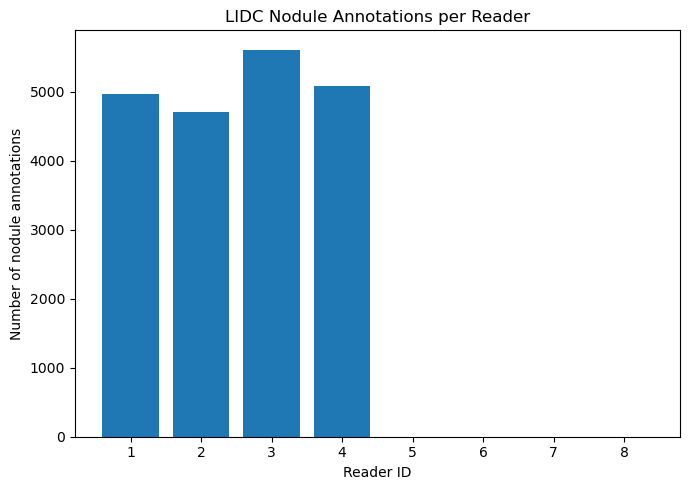

In [23]:
reader_counts = (
    lidc_xml_nodules_df
    .groupby("reader_id")
    .size()
    .reset_index(name="nodule_annotation_count")
)

display(reader_counts)

reader_counts.to_csv(TABLE_DIR / "lidc_reader_annotation_counts.csv", index=False)

plt.figure(figsize=(7, 5))
plt.bar(reader_counts["reader_id"], reader_counts["nodule_annotation_count"])
plt.xlabel("Reader ID")
plt.ylabel("Number of nodule annotations")
plt.title("LIDC Nodule Annotations per Reader")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "lidc_reader_annotation_counts.png", dpi=300)
plt.show()

count    20362.000000
mean        86.906885
std        269.554030
min          1.000000
25%          1.000000
50%          1.000000
75%         69.000000
max       6814.000000
Name: edge_point_count, dtype: float64


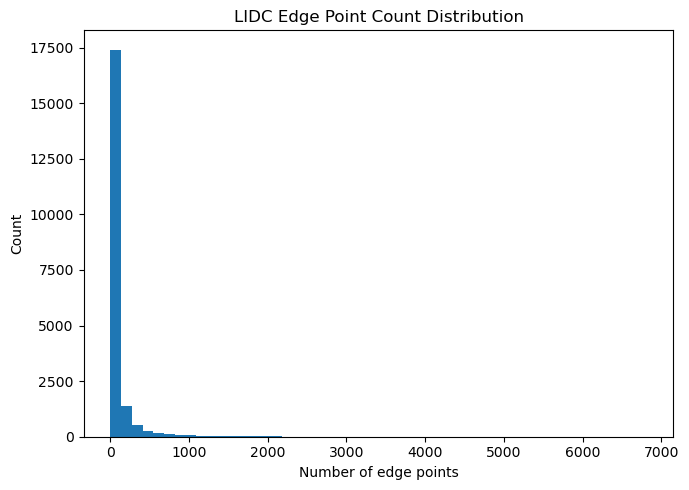

In [24]:
print(lidc_xml_nodules_df["edge_point_count"].describe())

plt.figure(figsize=(7, 5))
plt.hist(lidc_xml_nodules_df["edge_point_count"].dropna(), bins=50)
plt.xlabel("Number of edge points")
plt.ylabel("Count")
plt.title("LIDC Edge Point Count Distribution")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "lidc_edge_point_count_distribution.png", dpi=300)
plt.show()